# Universal Semantic Manifold — Cloud Scale

**Goal**: push USM to cloud-GPU scale with adaptive configuration.

| Dimension | Validation | T4 (Colab) | Cloud GPU (A100/L4) |
|---|---|---|---|
| Concepts | ~377 | 85K+ | 300K+ |
| Manifold dim | d=256 | d=512 | d=1024 |
| CLIP backbone | — | ViT-B/32 | ViT-L/14 |
| Modalities | text only | text + vision | text + vision |
| Languages | EN + FR | EN + FR + DE + ES | EN + FR + DE + ES |
| Epochs | 20 | 30+30 | 60+60 |
| Evaluation | 4 analogies | MRR, Hits@K, R@K | MRR, Hits@K, R@K |
| Baseline | none | Euclidean | Euclidean |

**Auto-scales** based on detected GPU VRAM (24 GB+ = full scale).

---
**References**
- Nickel & Kiela (2017) — Poincaré Embeddings for Learning Hierarchical Representations
- Mathieu et al. (2019) — Continuous Hierarchical Representations with Poincaré VAEs
- Radford et al. (2021) — Learning Transferable Visual Models From Natural Language Supervision (CLIP)
- Desai et al. (2023) — Hyperbolic Image-Text Representations (MERU)
- HypStructure (NeurIPS 2024) — Learning Structured Representations with Hyperbolic Embeddings

## Section 0 — Setup

In [1]:
%uv pip install -q geoopt sentence-transformers datasets umap-learn seaborn tqdm \
    transformers open_clip_torch Pillow torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, math, random, warnings, re
from typing import List, Tuple, Dict, Optional
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import geoopt
from geoopt.optim import RiemannianAdam

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm, trange

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

VRAM_GB = 0
if torch.cuda.is_available():
    VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
    print(f'VRAM:   {VRAM_GB:.1f} GB')

# ── Adaptive config based on available VRAM ────────────────────────────────────
# Cloud GPU (A100/L4/A10G 24GB+): full scale
# T4 / consumer GPU (12-16 GB): medium scale
LARGE_GPU = VRAM_GB >= 24

D          = 1024 if LARGE_GPU else 512
D_BACKBONE = 384                                      # MiniLM output dim
CLIP_MODEL = 'openai/clip-vit-large-patch14' if LARGE_GPU else 'openai/clip-vit-base-patch32'
D_CLIP     = 768 if LARGE_GPU else 512                # CLIP output dim

N_EPOCHS_P1 = 60 if LARGE_GPU else 30
N_EPOCHS_P2 = 60 if LARGE_GPU else 30
BATCH_SIZE  = 256 if LARGE_GPU else 128
MAX_CN_TRIPLES = 400000 if LARGE_GPU else 100000
LR_P1       = 5e-4
LR_P2_VIS   = 3e-4
LR_P2_TEXT  = 1e-5                                    # slow text fine-tuning in Phase 2

ball = geoopt.PoincareBall(c=1.0)
print(f'\nManifold: Poincaré ball, d={D}, curvature c={ball.c.item():.1f}')
print(f'CLIP:     {CLIP_MODEL}')
print(f'Epochs:   P1={N_EPOCHS_P1}, P2={N_EPOCHS_P2}')
print(f'Batch:    {BATCH_SIZE}')
print(f'ConceptNet target: {MAX_CN_TRIPLES:,} triples')
print(f'Scale:    {"LARGE (cloud GPU)" if LARGE_GPU else "MEDIUM (T4/consumer)"}')

Device: cuda
GPU:    NVIDIA A100 80GB PCIe
VRAM:   85.1 GB

Manifold: Poincaré ball, d=1024, curvature c=1.0
CLIP:     openai/clip-vit-large-patch14
Epochs:   P1=60, P2=60
Batch:    256
ConceptNet target: 400,000 triples
Scale:    LARGE (cloud GPU)


## Section 1 — Hyperbolic Math Primitives

Proven stable from the validation notebook. All operations clamp to $\|z\| \leq 1 - \varepsilon$.

In [3]:
EPS      = 1e-5
MAX_NORM = 1.0 - EPS


def clamp_to_ball(z: torch.Tensor, eps: float = EPS) -> torch.Tensor:
    norms = z.norm(dim=-1, keepdim=True).clamp(min=1e-10)
    max_n = 1.0 - eps
    scale = torch.where(norms >= max_n, max_n / norms, torch.ones_like(norms))
    return z * scale


def expmap0(v: torch.Tensor) -> torch.Tensor:
    return clamp_to_ball(ball.expmap0(v))


def logmap0(z: torch.Tensor) -> torch.Tensor:
    return ball.logmap0(clamp_to_ball(z))


def expmap(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    return clamp_to_ball(ball.expmap(clamp_to_ball(x), v))


def poincare_dist(z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
    z1 = clamp_to_ball(z1)
    z2 = clamp_to_ball(z2)
    diff_sq = (z1 - z2).pow(2).sum(dim=-1)
    n1_sq   = z1.pow(2).sum(dim=-1)
    n2_sq   = z2.pow(2).sum(dim=-1)
    denom   = ((1.0 - n1_sq) * (1.0 - n2_sq)).clamp(min=EPS)
    arg     = 1.0 + 2.0 * diff_sq / denom
    return torch.acosh(arg.clamp(min=1.0))


def poincare_cdist(z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
    z1 = clamp_to_ball(z1)
    z2 = clamp_to_ball(z2)
    n1_sq   = z1.pow(2).sum(dim=-1, keepdim=True)
    n2_sq   = z2.pow(2).sum(dim=-1, keepdim=True).T
    dot     = z1 @ z2.T
    diff_sq = (n1_sq + n2_sq - 2.0 * dot).clamp(min=0.0)
    denom   = ((1.0 - n1_sq) * (1.0 - n2_sq)).clamp(min=EPS)
    arg     = 1.0 + 2.0 * diff_sq / denom
    return torch.acosh(arg.clamp(min=1.0 + 1e-6))


def dist0(z: torch.Tensor) -> torch.Tensor:
    z = clamp_to_ball(z)
    n_sq  = z.pow(2).sum(dim=-1)
    arg   = 1.0 + 2.0 * n_sq / (1.0 - n_sq).clamp(min=EPS)
    return torch.acosh(arg.clamp(min=1.0))


# --- Euclidean equivalents (for baseline comparison) ---
def eucl_dist(z1, z2):
    return (z1 - z2).pow(2).sum(dim=-1).sqrt()


def eucl_cdist(z1, z2):
    return torch.cdist(z1, z2, p=2)


print('Primitives loaded (Poincaré + Euclidean).')

Primitives loaded (Poincaré + Euclidean).


## Section 2 — Concept Encoder (Text)

In [4]:
from sentence_transformers import SentenceTransformer


class ConceptEncoder(nn.Module):
    def __init__(self, backbone='paraphrase-multilingual-MiniLM-L12-v2',
                 d_out=D, hyperbolic=True):
        super().__init__()
        self.hyperbolic = hyperbolic
        self.backbone = SentenceTransformer(backbone, device=str(device))
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        d_in = self.backbone.get_sentence_embedding_dimension()
        self.proj = nn.Sequential(nn.Linear(d_in, d_out), nn.LayerNorm(d_out))
        if hyperbolic:
            self.mu0 = geoopt.ManifoldParameter(torch.zeros(d_out), manifold=ball)

    @torch.no_grad()
    def encode_backbone(self, texts: List[str]) -> torch.Tensor:
        embs = self.backbone.encode(texts, convert_to_tensor=True, show_progress_bar=False)
        return embs.to(device).float().clone()

    def project(self, bb_emb: torch.Tensor) -> torch.Tensor:
        bb_emb = bb_emb.clone()
        v = self.proj(bb_emb)
        if self.hyperbolic:
            mu0 = self.mu0.unsqueeze(0).expand(v.shape[0], -1)
            return clamp_to_ball(expmap(mu0, v))
        return v  # Euclidean: raw projection output

    def forward(self, texts: List[str]) -> Tuple[torch.Tensor, torch.Tensor]:
        bb_emb = self.encode_backbone(texts)
        z = self.project(bb_emb)
        return z, bb_emb


print('Initialising ConceptEncoder...')
encoder = ConceptEncoder(hyperbolic=True).to(device)

with torch.no_grad():
    z_test, _ = encoder(['dog', 'cat', 'fire'])
assert z_test.shape == (3, D) and (z_test.norm(dim=-1) < 1.0).all()
print(f'ConceptEncoder OK. Output: {z_test.shape}, norms < 1  ✓')
n_train = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'Trainable params: {n_train:,}')

Initialising ConceptEncoder...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ConceptEncoder OK. Output: torch.Size([3, 1024]), norms < 1  ✓
Trainable params: 397,312


## Section 2b — Vision Encoder (CLIP)

In [5]:
from transformers import CLIPModel, CLIPProcessor


class VisionEncoder(nn.Module):
    def __init__(self, d_out=D, hyperbolic=True, clip_model=CLIP_MODEL, d_clip=D_CLIP):
        super().__init__()
        self.hyperbolic = hyperbolic
        self.clip = CLIPModel.from_pretrained(clip_model)
        self.clip.eval()
        for p in self.clip.parameters():
            p.requires_grad_(False)
        self.proj = nn.Sequential(nn.Linear(d_clip, d_out), nn.LayerNorm(d_out))
        if hyperbolic:
            self.mu0 = geoopt.ManifoldParameter(torch.zeros(d_out), manifold=ball)

    @torch.no_grad()
    def encode_images(self, pixel_values: torch.Tensor) -> torch.Tensor:
        vision_out = self.clip.vision_model(pixel_values=pixel_values.to(device))
        pooled = vision_out.pooler_output                       # [B, D_CLIP]
        pooled = self.clip.visual_projection(pooled)            # [B, D_CLIP] projected
        return pooled.float()

    def project(self, clip_emb: torch.Tensor) -> torch.Tensor:
        clip_emb = clip_emb.clone()
        v = self.proj(clip_emb)
        if self.hyperbolic:
            mu0 = self.mu0.unsqueeze(0).expand(v.shape[0], -1)
            return clamp_to_ball(expmap(mu0, v))
        return v

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        clip_emb = self.encode_images(pixel_values)
        return self.project(clip_emb)


print(f'Initialising VisionEncoder with {CLIP_MODEL} ...')
vis_encoder = VisionEncoder(hyperbolic=True).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)

n_vis_train = sum(p.numel() for p in vis_encoder.parameters() if p.requires_grad)
print(f'VisionEncoder OK. Trainable params: {n_vis_train:,}')

if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1e9
    print(f'GPU memory allocated: {alloc:.2f} GB')

Initialising VisionEncoder with openai/clip-vit-large-patch14 ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

VisionEncoder OK. Trainable params: 790,528
GPU memory allocated: 2.20 GB


## Section 3 — Compositional Operator & Relation Maps

In [6]:
RELATIONS  = ['IS_A', 'CAUSES', 'PART_OF', 'SIMILAR_TO', 'ANTONYM', 'CAPABLE_OF']
REL2IDX    = {r: i for i, r in enumerate(RELATIONS)}
N_RELATIONS = len(RELATIONS)

_SYMW = {'IS_A': 0.0, 'CAUSES': 0.0, 'PART_OF': 0.0,
         'SIMILAR_TO': 1.0, 'ANTONYM': 0.1, 'CAPABLE_OF': 0.0}
SYM_WEIGHTS = torch.tensor([_SYMW[r] for r in RELATIONS], dtype=torch.float32)


class CompositionalOperator(nn.Module):
    def __init__(self, d=D, n_rel=N_RELATIONS, hyperbolic=True):
        super().__init__()
        self.d = d
        self.hyperbolic = hyperbolic
        init = lambda: (torch.eye(d).unsqueeze(0).repeat(n_rel, 1, 1)
                        + 0.01 * torch.randn(n_rel, d, d))
        self.W     = nn.Parameter(init())
        self.U_raw = nn.Parameter(init())
        self.V     = nn.Parameter(0.01 * torch.randn(n_rel, d, d))
        self.b     = nn.Parameter(torch.zeros(n_rel, d))
        self.register_buffer('sym_w', SYM_WEIGHTS)

    def effective_U(self):
        s = self.sym_w.view(-1, 1, 1)
        return s * self.W + (1.0 - s) * self.U_raw

    def forward(self, z_A, rel_idx, z_B):
        if self.hyperbolic:
            a, b = logmap0(z_A), logmap0(z_B)
        else:
            a, b = z_A, z_B
        U_eff = self.effective_U()
        W_r = self.W[rel_idx]; U_r = U_eff[rel_idx]
        V_r = self.V[rel_idx]; b_r = self.b[rel_idx]
        out = torch.tanh(
            torch.einsum('bij,bj->bi', W_r, a)
            + torch.einsum('bij,bj->bi', U_r, b)
            + torch.einsum('bij,bj->bi', V_r, a * b) + b_r
        )
        return clamp_to_ball(expmap0(out)) if self.hyperbolic else out


class RelationMaps(nn.Module):
    def __init__(self, d=D, n_rel=N_RELATIONS, hyperbolic=True):
        super().__init__()
        self.hyperbolic = hyperbolic
        self.W = nn.Parameter(torch.eye(d).unsqueeze(0).repeat(n_rel, 1, 1)
                              + 0.01 * torch.randn(n_rel, d, d))
        self.b = nn.Parameter(torch.zeros(n_rel, d))

    def forward(self, z_h, rel_idx):
        h = logmap0(z_h) if self.hyperbolic else z_h
        W_r = self.W[rel_idx]; b_r = self.b[rel_idx]
        out = torch.einsum('bij,bj->bi', W_r, h) + b_r
        return clamp_to_ball(expmap0(out)) if self.hyperbolic else out


comp_op  = CompositionalOperator(hyperbolic=True).to(device)
rel_maps = RelationMaps(hyperbolic=True).to(device)
print(f'CompositionalOperator params: {sum(p.numel() for p in comp_op.parameters()):,}')
print(f'RelationMaps params:          {sum(p.numel() for p in rel_maps.parameters()):,}')

CompositionalOperator params: 18,880,512
RelationMaps params:          6,297,600


## Section 4 — Data Loading (scaled)

In [7]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

# ── ConceptNet ─────────────────────────────────────────────────────────────────
_CN_MAP = {
    '/r/IsA': 'IS_A', 'IsA': 'IS_A', 'is_a': 'IS_A',
    '/r/Causes': 'CAUSES', 'Causes': 'CAUSES', 'causes': 'CAUSES',
    '/r/PartOf': 'PART_OF', 'PartOf': 'PART_OF', 'part_of': 'PART_OF',
    '/r/SimilarTo': 'SIMILAR_TO', 'SimilarTo': 'SIMILAR_TO', 'similar_to': 'SIMILAR_TO',
    '/r/Antonym': 'ANTONYM', 'Antonym': 'ANTONYM', 'antonym': 'ANTONYM',
    '/r/CapableOf': 'CAPABLE_OF', 'CapableOf': 'CAPABLE_OF', 'capable_of': 'CAPABLE_OF',
}

def _norm_concept(s):
    s = str(s).strip()
    if '/c/en/' in s:
        s = s.split('/c/en/')[-1]
        s = s.split('/')[0]  # strip POS tag e.g. /c/en/dog/n -> dog
    elif '/' in s:
        s = s.split('/')[-1]
    s = re.sub(r'[^a-z ]', '', s.replace('_', ' ').lower()).strip()
    return s if len(s) > 1 else None


_FALLBACK_TRIPLES = [
    ('dog','IS_A','animal'), ('cat','IS_A','animal'), ('wolf','IS_A','animal'),
    ('eagle','IS_A','bird'), ('robin','IS_A','bird'), ('penguin','IS_A','bird'),
    ('salmon','IS_A','fish'), ('shark','IS_A','fish'),
    ('rose','IS_A','flower'), ('tulip','IS_A','flower'), ('daisy','IS_A','flower'),
    ('oak','IS_A','tree'), ('pine','IS_A','tree'), ('maple','IS_A','tree'),
    ('hammer','IS_A','tool'), ('wrench','IS_A','tool'), ('saw','IS_A','tool'),
    ('violin','IS_A','instrument'), ('piano','IS_A','instrument'), ('guitar','IS_A','instrument'),
    ('python','IS_A','programming language'), ('java','IS_A','programming language'),
    ('algebra','IS_A','mathematics'), ('geometry','IS_A','mathematics'),
    ('democracy','IS_A','government'), ('monarchy','IS_A','government'),
    ('jazz','IS_A','music'), ('blues','IS_A','music'), ('classical','IS_A','music'),
    ('mars','IS_A','planet'), ('venus','IS_A','planet'), ('jupiter','IS_A','planet'),
    ('gold','IS_A','metal'), ('iron','IS_A','metal'), ('copper','IS_A','metal'),
    ('paris','IS_A','city'), ('berlin','IS_A','city'), ('tokyo','IS_A','city'),
    ('apple','IS_A','fruit'), ('orange','IS_A','fruit'), ('banana','IS_A','fruit'),
    ('broccoli','IS_A','vegetable'), ('carrot','IS_A','vegetable'),
    ('fire','CAUSES','smoke'), ('fire','CAUSES','heat'), ('fire','CAUSES','destruction'),
    ('rain','CAUSES','flooding'), ('rain','CAUSES','erosion'),
    ('exercise','CAUSES','fatigue'), ('exercise','CAUSES','strength'),
    ('stress','CAUSES','anxiety'), ('stress','CAUSES','illness'),
    ('infection','CAUSES','fever'), ('infection','CAUSES','inflammation'),
    ('friction','CAUSES','heat'), ('deforestation','CAUSES','erosion'),
    ('pollution','CAUSES','disease'), ('drought','CAUSES','famine'),
    ('wheel','PART_OF','car'), ('engine','PART_OF','car'), ('door','PART_OF','car'),
    ('leaf','PART_OF','tree'), ('branch','PART_OF','tree'), ('root','PART_OF','tree'),
    ('petal','PART_OF','flower'), ('stem','PART_OF','flower'),
    ('chapter','PART_OF','book'), ('sentence','PART_OF','paragraph'),
    ('atom','PART_OF','molecule'), ('cell','PART_OF','organism'),
    ('finger','PART_OF','hand'), ('toe','PART_OF','foot'), ('pupil','PART_OF','eye'),
    ('happy','SIMILAR_TO','joyful'), ('sad','SIMILAR_TO','unhappy'),
    ('fast','SIMILAR_TO','quick'), ('big','SIMILAR_TO','large'),
    ('beautiful','SIMILAR_TO','attractive'), ('smart','SIMILAR_TO','intelligent'),
    ('cold','SIMILAR_TO','chilly'), ('warm','SIMILAR_TO','tepid'),
    ('walk','SIMILAR_TO','stroll'), ('speak','SIMILAR_TO','talk'),
    ('bright','SIMILAR_TO','luminous'), ('dark','SIMILAR_TO','dim'),
    ('ancient','SIMILAR_TO','old'), ('modern','SIMILAR_TO','contemporary'),
    ('strong','SIMILAR_TO','powerful'),
    ('hot','ANTONYM','cold'), ('fast','ANTONYM','slow'),
    ('love','ANTONYM','hate'), ('light','ANTONYM','dark'),
    ('begin','ANTONYM','end'), ('win','ANTONYM','lose'),
    ('north','ANTONYM','south'), ('open','ANTONYM','closed'),
    ('happy','ANTONYM','sad'), ('old','ANTONYM','young'),
    ('up','ANTONYM','down'), ('left','ANTONYM','right'),
    ('give','ANTONYM','take'), ('create','ANTONYM','destroy'),
    ('honest','ANTONYM','dishonest'),
    ('dog','CAPABLE_OF','barking'), ('dog','CAPABLE_OF','running'),
    ('bird','CAPABLE_OF','flying'), ('bird','CAPABLE_OF','singing'),
    ('fish','CAPABLE_OF','swimming'), ('human','CAPABLE_OF','thinking'),
    ('human','CAPABLE_OF','speaking'), ('computer','CAPABLE_OF','calculation'),
    ('car','CAPABLE_OF','moving'), ('tree','CAPABLE_OF','photosynthesis'),
    ('eye','CAPABLE_OF','seeing'), ('muscle','CAPABLE_OF','contracting'),
    ('brain','CAPABLE_OF','learning'), ('fire','CAPABLE_OF','burning'),
    ('knife','CAPABLE_OF','cutting'),
    ('lion','IS_A','animal'), ('bear','IS_A','animal'), ('horse','IS_A','animal'),
    ('rabbit','IS_A','animal'), ('deer','IS_A','animal'), ('fox','IS_A','animal'),
    ('sparrow','IS_A','bird'), ('hawk','IS_A','bird'), ('owl','IS_A','bird'),
    ('tuna','IS_A','fish'), ('trout','IS_A','fish'), ('whale','IS_A','mammal'),
    ('dolphin','IS_A','mammal'), ('bat','IS_A','mammal'),
    ('lily','IS_A','flower'), ('orchid','IS_A','flower'), ('sunflower','IS_A','flower'),
    ('birch','IS_A','tree'), ('willow','IS_A','tree'), ('cedar','IS_A','tree'),
    ('screwdriver','IS_A','tool'), ('pliers','IS_A','tool'), ('drill','IS_A','tool'),
    ('drum','IS_A','instrument'), ('flute','IS_A','instrument'), ('trumpet','IS_A','instrument'),
    ('ruby','IS_A','programming language'), ('rust','IS_A','programming language'),
    ('calculus','IS_A','mathematics'), ('statistics','IS_A','mathematics'),
    ('republic','IS_A','government'), ('dictatorship','IS_A','government'),
    ('rock','IS_A','music'), ('pop','IS_A','music'), ('hip hop','IS_A','music'),
    ('saturn','IS_A','planet'), ('neptune','IS_A','planet'), ('mercury','IS_A','planet'),
    ('silver','IS_A','metal'), ('platinum','IS_A','metal'), ('titanium','IS_A','metal'),
    ('london','IS_A','city'), ('rome','IS_A','city'), ('sydney','IS_A','city'),
    ('mango','IS_A','fruit'), ('grape','IS_A','fruit'), ('cherry','IS_A','fruit'),
    ('spinach','IS_A','vegetable'), ('onion','IS_A','vegetable'), ('potato','IS_A','vegetable'),
    ('chair','IS_A','furniture'), ('table','IS_A','furniture'), ('sofa','IS_A','furniture'),
    ('soccer','IS_A','sport'), ('tennis','IS_A','sport'), ('basketball','IS_A','sport'),
    ('english','IS_A','language'), ('spanish','IS_A','language'), ('mandarin','IS_A','language'),
    ('oxygen','IS_A','element'), ('hydrogen','IS_A','element'), ('carbon','IS_A','element'),
    ('novel','IS_A','literature'), ('poem','IS_A','literature'), ('essay','IS_A','literature'),
    ('lightning','CAUSES','fire'), ('earthquake','CAUSES','destruction'),
    ('virus','CAUSES','disease'), ('bacteria','CAUSES','infection'),
    ('gravity','CAUSES','falling'), ('heat','CAUSES','evaporation'),
    ('wind','CAUSES','erosion'), ('cold','CAUSES','freezing'),
    ('anger','CAUSES','violence'), ('hunger','CAUSES','weakness'),
    ('sleep deprivation','CAUSES','fatigue'), ('smoking','CAUSES','cancer'),
    ('education','CAUSES','knowledge'), ('practice','CAUSES','improvement'),
    ('sunlight','CAUSES','photosynthesis'), ('pressure','CAUSES','stress'),
    ('alcohol','CAUSES','intoxication'), ('sugar','CAUSES','energy'),
    ('roof','PART_OF','house'), ('wall','PART_OF','house'), ('window','PART_OF','house'),
    ('keyboard','PART_OF','computer'), ('screen','PART_OF','computer'), ('cpu','PART_OF','computer'),
    ('wing','PART_OF','bird'), ('beak','PART_OF','bird'), ('feather','PART_OF','bird'),
    ('paw','PART_OF','dog'), ('tail','PART_OF','dog'), ('fur','PART_OF','dog'),
    ('nucleus','PART_OF','cell'), ('membrane','PART_OF','cell'),
    ('string','PART_OF','guitar'), ('fret','PART_OF','guitar'),
    ('page','PART_OF','book'), ('spine','PART_OF','book'), ('cover','PART_OF','book'),
    ('petal','PART_OF','rose'), ('thorn','PART_OF','rose'),
    ('blade','PART_OF','knife'), ('handle','PART_OF','knife'),
    ('angry','SIMILAR_TO','furious'), ('scared','SIMILAR_TO','afraid'),
    ('tired','SIMILAR_TO','exhausted'), ('tiny','SIMILAR_TO','small'),
    ('huge','SIMILAR_TO','enormous'), ('clever','SIMILAR_TO','smart'),
    ('wealthy','SIMILAR_TO','rich'), ('poor','SIMILAR_TO','impoverished'),
    ('swift','SIMILAR_TO','fast'), ('gentle','SIMILAR_TO','soft'),
    ('brave','SIMILAR_TO','courageous'), ('shy','SIMILAR_TO','timid'),
    ('calm','SIMILAR_TO','peaceful'), ('loud','SIMILAR_TO','noisy'),
    ('clean','SIMILAR_TO','tidy'), ('dirty','SIMILAR_TO','filthy'),
    ('rich','ANTONYM','poor'), ('strong','ANTONYM','weak'),
    ('tall','ANTONYM','short'), ('heavy','ANTONYM','light'),
    ('deep','ANTONYM','shallow'), ('wide','ANTONYM','narrow'),
    ('bright','ANTONYM','dark'), ('loud','ANTONYM','quiet'),
    ('brave','ANTONYM','cowardly'), ('kind','ANTONYM','cruel'),
    ('hard','ANTONYM','soft'), ('dry','ANTONYM','wet'),
    ('rough','ANTONYM','smooth'), ('cheap','ANTONYM','expensive'),
    ('ancient','ANTONYM','modern'), ('simple','ANTONYM','complex'),
    ('horse','CAPABLE_OF','galloping'), ('eagle','CAPABLE_OF','soaring'),
    ('snake','CAPABLE_OF','slithering'), ('frog','CAPABLE_OF','jumping'),
    ('spider','CAPABLE_OF','weaving'), ('bee','CAPABLE_OF','pollinating'),
    ('wind','CAPABLE_OF','blowing'), ('river','CAPABLE_OF','flowing'),
    ('sun','CAPABLE_OF','shining'), ('plant','CAPABLE_OF','growing'),
    ('teacher','CAPABLE_OF','teaching'), ('doctor','CAPABLE_OF','healing'),
    ('artist','CAPABLE_OF','creating'), ('scientist','CAPABLE_OF','researching'),
    ('volcano','CAPABLE_OF','erupting'), ('lightning','CAPABLE_OF','striking'),
]


def _augment_triples(triples):
    augmented = list(triples)
    for h, r, t in triples:
        if r in ('SIMILAR_TO', 'ANTONYM'):
            augmented.append((t, r, h))
    isa_groups = defaultdict(list)
    for h, r, t in triples:
        if r == 'IS_A':
            isa_groups[t].append(h)
    for parent, children in isa_groups.items():
        for i, c1 in enumerate(children):
            for c2 in children[i+1:]:
                augmented.append((c1, 'SIMILAR_TO', c2))
                augmented.append((c2, 'SIMILAR_TO', c1))
    return augmented


def _load_conceptnet_s3(max_triples=100000):
    """Stream ConceptNet 5.7 assertions directly from S3 (gzipped TSV)."""
    import urllib.request, gzip, io as _io
    url = 'https://s3.amazonaws.com/conceptnet/downloads/2019/edges/conceptnet-assertions-5.7.0.csv.gz'
    print('  Streaming ConceptNet 5.7 from S3 (~80s for 100K triples)...')
    resp = urllib.request.urlopen(url, timeout=30)
    reader = _io.TextIOWrapper(gzip.GzipFile(fileobj=resp), encoding='utf-8')
    triples = []
    scanned = 0
    for line in reader:
        scanned += 1
        parts = line.strip().split('\t')
        if len(parts) < 5:
            continue
        rel, head, tail = parts[1], parts[2], parts[3]
        if not head.startswith('/c/en/') or not tail.startswith('/c/en/'):
            continue
        r = _CN_MAP.get(rel)
        if not r:
            continue
        h = _norm_concept(head)
        t = _norm_concept(tail)
        if h and t and h != t:
            triples.append((h, r, t))
        if len(triples) >= max_triples:
            break
        if scanned % 2000000 == 0:
            print(f'    ...{scanned//1000000}M rows, {len(triples):,} triples so far')
    reader.close()
    return triples


def load_conceptnet(max_triples=100000):
    # Attempt 1 — stream directly from S3 (most reliable, ~80s)
    try:
        triples = _load_conceptnet_s3(max_triples)
        if triples:
            from collections import Counter
            rc = Counter(r for _, r, _ in triples)
            print(f'  ✓  {len(triples):,} triples from S3 ({dict(rc)})')
            return triples
    except Exception as e:
        print(f'  ✗  S3 streaming failed: {e}')

    # Attempt 2 — HuggingFace conceptnet5/conceptnet5 (streaming)
    try:
        print('  Trying conceptnet5/conceptnet5 (HuggingFace streaming)...')
        ds = load_dataset('conceptnet5/conceptnet5', split='train', streaming=True)
        triples = []
        for row in ds:
            if row.get('lang') != 'en':
                continue
            r = _CN_MAP.get(row.get('rel'))
            if not r:
                continue
            h = _norm_concept(row['arg1'])
            t = _norm_concept(row['arg2'])
            if h and t and h != t:
                triples.append((h, r, t))
            if len(triples) >= max_triples:
                break
        if triples:
            print(f'  ✓  {len(triples):,} triples from HuggingFace')
            return triples
    except Exception as e:
        print(f'  ✗  HuggingFace failed: {e}')

    # Fallback — curated hardcoded set + augmentation
    augmented = _augment_triples(_FALLBACK_TRIPLES)
    print(f'  Using hardcoded fallback: {len(_FALLBACK_TRIPLES)} base + '
          f'{len(augmented)-len(_FALLBACK_TRIPLES)} augmented = {len(augmented)} triples')
    return augmented


# ── Cross-lingual (multi-language) ─────────────────────────────────────────────
def load_crosslingual(max_per_lang=20000):
    pairs = []
    for lang in ['en-fr', 'en-de', 'en-es']:
        try:
            print(f'  Trying tatoeba {lang}...')
            ds = load_dataset('sentence-transformers/parallel-sentences-tatoeba',
                              lang, split='train', trust_remote_code=True)
            lp = [(r['english'].strip(), r['non_english'].strip())
                  for r in ds if r['english'].strip() and r['non_english'].strip()]
            pairs.extend(lp[:max_per_lang])
            print(f'  ✓  {min(len(lp), max_per_lang)} pairs from tatoeba {lang}')
        except Exception as e:
            print(f'  ✗  tatoeba {lang}: {e}')
    if not pairs:
        print('  Using synthetic fallback (EN-FR/DE/ES)')
        pairs = [
            ('A dog is a domesticated animal.', 'Un chien est un animal domestiqué.'),
            ('Fire causes smoke.', 'Le feu cause de la fumée.'),
            ('Happy means feeling joyful.', 'Heureux signifie ressentir de la joie.'),
            ('Water covers most of the Earth.', "L'eau couvre la majeure partie de la Terre."),
            ('A dog is a domesticated animal.', 'Ein Hund ist ein domestiziertes Tier.'),
            ('Fire causes smoke.', 'Feuer verursacht Rauch.'),
            ('A dog is a domesticated animal.', 'Un perro es un animal domesticado.'),
            ('Fire causes smoke.', 'El fuego causa humo.'),
        ] * 20
    return pairs


def load_snli(max_pairs=20000):
    try:
        ds = load_dataset('snli', split=f'train[:{max_pairs}]')
        pairs = [(r['premise'], r['hypothesis'], r['label'])
                 for r in ds if r['label'] in (0, 1, 2)]
        print(f'  ✓  {len(pairs)} SNLI pairs')
        return pairs
    except Exception as e:
        print(f'  ✗  SNLI failed: {e}')
    # Fallback from ConceptNet IS_A / ANTONYM
    print('  Building SNLI-style fallback from hardcoded ConceptNet...')
    pairs = []
    for h, r, t in _FALLBACK_TRIPLES:
        if r == 'IS_A':
            pairs.append((f'A {h} is an example.', f'A {t} is an example.', 0))
            pairs.append((f'A {h} is an example.', f'Something unrelated happened.', 1))
        elif r == 'ANTONYM':
            pairs.append((f'{h} is the topic.', f'{t} is the topic.', 2))
    print(f'  ✓  {len(pairs)} fallback SNLI-style pairs')
    return pairs


# ── CIFAR-100 (images + hierarchy) ─────────────────────────────────────────────
CIFAR100_COARSE = [
    'aquatic mammals', 'fish', 'flowers', 'food containers', 'fruit and vegetables',
    'household electrical devices', 'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor things', 'large natural outdoor scenes',
    'large omnivores and herbivores', 'medium-sized mammals', 'non-insect invertebrates',
    'people', 'reptiles', 'small mammals', 'trees', 'vehicles 1', 'vehicles 2',
]
CIFAR100_FINE = [
    'apple', 'aquarium fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak tree', 'orange', 'orchid', 'otter', 'palm tree', 'pear',
    'pickup truck', 'pine tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow tree', 'wolf', 'woman', 'worm',
]
CIFAR100_FINE2COARSE = {
    0:4, 1:1, 2:14, 3:8, 4:0, 5:6, 6:7, 7:7, 8:18, 9:3, 10:3, 11:14, 12:9,
    13:18, 14:7, 15:11, 16:3, 17:9, 18:7, 19:11, 20:6, 21:11, 22:5, 23:10,
    24:7, 25:6, 26:13, 27:15, 28:3, 29:15, 30:0, 31:11, 32:1, 33:10, 34:12,
    35:14, 36:16, 37:9, 38:11, 39:5, 40:5, 41:19, 42:8, 43:8, 44:15, 45:13,
    46:14, 47:17, 48:18, 49:10, 50:16, 51:4, 52:17, 53:4, 54:2, 55:0, 56:17,
    57:4, 58:18, 59:17, 60:10, 61:3, 62:2, 63:12, 64:12, 65:16, 66:12, 67:1,
    68:9, 69:19, 70:2, 71:10, 72:0, 73:1, 74:16, 75:12, 76:9, 77:13, 78:15,
    79:13, 80:16, 81:19, 82:2, 83:4, 84:6, 85:19, 86:5, 87:5, 88:8, 89:19,
    90:18, 91:1, 92:2, 93:15, 94:6, 95:0, 96:17, 97:8, 98:14, 99:13,
}

print('Loading data...')
cn_triples = load_conceptnet(max_triples=MAX_CN_TRIPLES)
cl_pairs   = load_crosslingual(max_per_lang=20000)
snli_pairs = load_snli(max_pairs=20000)

# Build vocabulary
vocab_set = set()
for h, r, t in cn_triples:
    vocab_set.add(h); vocab_set.add(t)
vocab_list = sorted(vocab_set)

# Train/test split for ConceptNet (80/20)
random.shuffle(cn_triples)
split = int(0.8 * len(cn_triples))
cn_train, cn_test = cn_triples[:split], cn_triples[split:]

print(f'\nConceptNet: {len(cn_triples):,} total ({len(cn_train):,} train / {len(cn_test):,} test)')
print(f'Unique concepts: {len(vocab_list):,}')
print(f'Cross-lingual:   {len(cl_pairs):,}')
print(f'SNLI:            {len(snli_pairs):,}')

# CIFAR-100
print('\nLoading CIFAR-100...')
cifar_transform = T.Compose([T.Resize(224), T.CenterCrop(224), T.ToTensor(),
                             T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
cifar_train = torchvision.datasets.CIFAR100(root='./data', train=True,
                                            download=True, transform=cifar_transform)
cifar_test  = torchvision.datasets.CIFAR100(root='./data', train=False,
                                            download=True, transform=cifar_transform)
print(f'CIFAR-100 train: {len(cifar_train):,}  test: {len(cifar_test):,}')
print(f'Fine classes: {len(CIFAR100_FINE)}  Coarse classes: {len(CIFAR100_COARSE)}')

Loading data...
  Streaming ConceptNet 5.7 from S3 (~80s for 100K triples)...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'sentence-transformers/parallel-sentences-tatoeba' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  ✓  329,875 triples from S3 ({'ANTONYM': 19047, 'CAPABLE_OF': 22658, 'CAUSES': 16670, 'IS_A': 229117, 'PART_OF': 12561, 'SIMILAR_TO': 29822})
  Trying tatoeba en-fr...


README.md: 0.00B [00:00, ?B/s]

en-fr/dev-00000-of-00001.parquet:   0%|          | 0.00/87.2k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

  ✓  19978 SNLI pairs

ConceptNet: 329,875 total (263,900 train / 65,975 test)
Unique concepts: 209,872
Cross-lingual:   60,000
SNLI:            19,978

Loading CIFAR-100...


100%|███████████████████████████████████████████████████████████████████████| 169M/169M [00:02<00:00, 70.6MB/s]


CIFAR-100 train: 50,000  test: 10,000
Fine classes: 100  Coarse classes: 20


In [8]:
# ── DataLoaders ────────────────────────────────────────────────────────────────

class KGDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples
    def __len__(self): return len(self.triples)
    def __getitem__(self, i):
        h, r, t = self.triples[i]
        return h, REL2IDX[r], t

class PairDataset(Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

class SNLIDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = [(p, h, int(l)) for p, h, l in pairs if int(l) in (0,1,2)]
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

# BATCH_SIZE is set in the config cell above

def _safe_loader(ds, bs, **kw):
    if len(ds) == 0:
        return None
    bs = min(bs, len(ds))
    return DataLoader(ds, batch_size=bs, shuffle=True, drop_last=True, **kw)

kg_loader    = _safe_loader(KGDataset(cn_train), BATCH_SIZE)
cl_loader    = _safe_loader(PairDataset(cl_pairs), BATCH_SIZE)
snli_loader  = _safe_loader(SNLIDataset(snli_pairs), BATCH_SIZE)
cifar_batch = 128 if LARGE_GPU else 64
cifar_loader = _safe_loader(cifar_train, cifar_batch, num_workers=2)

for name, loader in [('KG', kg_loader), ('CL', cl_loader), ('SNLI', snli_loader), ('CIFAR', cifar_loader)]:
    print(f'{name:6s} batches: {len(loader) if loader else "SKIPPED (empty)"}')

KG     batches: 1030
CL     batches: 234
SNLI   batches: 78
CIFAR  batches: 390


## Section 5 — Loss Functions

In [9]:
def loss_cl(z_src, z_tgt, tau=1.0, hyperbolic=True):
    """InfoNCE with negative geodesic (or Euclidean) distance as similarity."""
    B = z_src.shape[0]
    cdist_fn = poincare_cdist if hyperbolic else eucl_cdist
    dists = cdist_fn(z_src, z_tgt)
    sim = -dists / tau
    labels = torch.arange(B, device=device)
    return 0.5 * (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels))


def loss_rel(z_pred, z_t, z_t_neg, margin=2.0, hyperbolic=True):
    """TransE-style margin loss."""
    dist_fn = poincare_dist if hyperbolic else eucl_dist
    d_pos = dist_fn(z_pred, z_t)
    d_neg = dist_fn(z_pred, z_t_neg)
    return F.relu(margin - d_neg + d_pos).mean()


def loss_entailment(z_A, z_B, labels, delta_c=2.0, hyperbolic=True):
    """Partial order + contradiction margin loss."""
    total, n = z_A.new_zeros(()), 0
    ent_mask = (labels == 0); contra_mask = (labels == 2)
    lm = logmap0 if hyperbolic else (lambda x: x)
    dist_fn = poincare_dist if hyperbolic else eucl_dist
    if ent_mask.any():
        a_e, b_e = lm(z_A[ent_mask]), lm(z_B[ent_mask])
        total = total + F.relu(b_e - a_e).pow(2).sum(-1).mean()
        n += 1
    if contra_mask.any():
        d_c = dist_fn(z_A[contra_mask], z_B[contra_mask])
        total = total + F.relu(delta_c - d_c).pow(2).mean()
        n += 1
    return total / max(n, 1)


def loss_crossmodal(z_text, z_image, tau=1.0, hyperbolic=True):
    """Cross-modal InfoNCE: pull text-image pairs together."""
    return loss_cl(z_text, z_image, tau=tau, hyperbolic=hyperbolic)


def loss_hierarchy(z_fine, z_coarse, margin=1.0, hyperbolic=True):
    """Fine-class embeddings should be deeper on the ball (higher norm) than coarse.
    Uses a soft margin ranking loss + entailment cone penalty."""
    if hyperbolic:
        depth_fine   = dist0(z_fine)
        depth_coarse = dist0(z_coarse)
    else:
        depth_fine   = z_fine.norm(dim=-1)
        depth_coarse = z_coarse.norm(dim=-1)
    # Margin ranking: fine should be deeper by at least `margin`
    L_rank = F.margin_ranking_loss(
        depth_fine, depth_coarse,
        target=torch.ones_like(depth_fine),
        margin=margin,
    )
    # Entailment penalty: fine should be close to coarse (they share a hierarchy)
    if hyperbolic:
        L_close = poincare_dist(z_fine, z_coarse).mean() * 0.1
    else:
        L_close = (z_fine - z_coarse).norm(dim=-1).mean() * 0.1
    return L_rank + L_close


print('All loss functions defined  ✓')

All loss functions defined  ✓


## Section 6 — Training

**Phase 1** (text only): ConceptNet + SNLI + cross-lingual.

**Phase 2** (multimodal, joint): Train vision projection + fine-tune text projection (low LR) + L_CM + L_HIER on CIFAR-100.

In [10]:
# ── Phase 1: Text-only training ───────────────────────────────────────────────
import glob

text_params = (
    list(encoder.proj.parameters()) + ([encoder.mu0] if hasattr(encoder, 'mu0') else [])
    + list(comp_op.parameters())
    + list(rel_maps.parameters())
)
opt_p1   = RiemannianAdam(text_params, lr=LR_P1, weight_decay=1e-4)
sched_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p1, T_max=N_EPOCHS_P1, eta_min=1e-5)

# ── A100 flags ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True

USE_BF16     = torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory >= 38e9
AMP_DTYPE    = torch.bfloat16 if USE_BF16 else torch.float16
GRAD_ACCUM   = 2 if USE_BF16 else 1
CKPT_DIR     = "/tmp/usm_checkpoints"
CKPT_EVERY   = 5
ENCODE_BATCH = 512 if USE_BF16 else 256
os.makedirs(CKPT_DIR, exist_ok=True)

# ── pre-cache vocab backbone (one-time ~15 min) ────────────────────────────────
VOCAB_CACHE_PATH = f"{CKPT_DIR}/vocab_bb_cache.pt"
if os.path.exists(VOCAB_CACHE_PATH):
    print("Loading vocab cache ...")
    vocab_bb_tensor = torch.load(VOCAB_CACHE_PATH, map_location='cpu')
    print(f"  Loaded: {vocab_bb_tensor.shape}  ({vocab_bb_tensor.nbytes/1e9:.2f} GB)")
else:
    print(f"Pre-encoding {len(vocab_list):,} concepts (one-time, ~15 min) ...")
    encoder.eval()
    all_bb = []
    with torch.no_grad():
        for i in tqdm(range(0, len(vocab_list), ENCODE_BATCH), desc='Vocab encode'):
            all_bb.append(encoder.encode_backbone(vocab_list[i:i+ENCODE_BATCH]).cpu())
    vocab_bb_tensor = torch.cat(all_bb)
    torch.save(vocab_bb_tensor, VOCAB_CACHE_PATH)
    print(f"  Saved → {VOCAB_CACHE_PATH}  ({vocab_bb_tensor.nbytes/1e9:.2f} GB)")

vocab2idx = {c: i for i, c in enumerate(vocab_list)}

def lookup_bb(concepts):
    idx = [vocab2idx[c] for c in concepts]
    return vocab_bb_tensor[idx].to(device, non_blocking=True)

# ── pre-cache CL pairs ─────────────────────────────────────────────────────────
CL_CACHE_PATH = f"{CKPT_DIR}/cl_bb_cache.pt"
if os.path.exists(CL_CACHE_PATH):
    print("Loading CL cache ...")
    cl_cache = torch.load(CL_CACHE_PATH, map_location='cpu')
    print(f"  Loaded: {cl_cache['src'].shape}")
else:
    print(f"Pre-encoding {len(cl_pairs):,} CL pairs ...")
    encoder.eval()
    src_texts = [p[0] for p in cl_pairs]
    tgt_texts = [p[1] for p in cl_pairs]
    with torch.no_grad():
        src_bb = torch.cat([
            encoder.encode_backbone(src_texts[i:i+ENCODE_BATCH]).cpu()
            for i in tqdm(range(0, len(src_texts), ENCODE_BATCH), desc='CL src')
        ])
        tgt_bb = torch.cat([
            encoder.encode_backbone(tgt_texts[i:i+ENCODE_BATCH]).cpu()
            for i in tqdm(range(0, len(tgt_texts), ENCODE_BATCH), desc='CL tgt')
        ])
    cl_cache = {'src': src_bb, 'tgt': tgt_bb}
    torch.save(cl_cache, CL_CACHE_PATH)
    print(f"  Saved → {CL_CACHE_PATH}")

# ── pre-cache SNLI pairs ───────────────────────────────────────────────────────
SNLI_CACHE_PATH = f"{CKPT_DIR}/snli_bb_cache.pt"
if os.path.exists(SNLI_CACHE_PATH):
    print("Loading SNLI cache ...")
    snli_cache = torch.load(SNLI_CACHE_PATH, map_location='cpu')
    print(f"  Loaded: {snli_cache['prem'].shape}")
else:
    print(f"Pre-encoding {len(snli_pairs):,} SNLI pairs ...")
    encoder.eval()
    prem_texts = [p[0] for p in snli_pairs]
    hyp_texts  = [p[1] for p in snli_pairs]
    snli_lbls  = torch.tensor([p[2] for p in snli_pairs], dtype=torch.long)
    with torch.no_grad():
        prem_bb = torch.cat([
            encoder.encode_backbone(prem_texts[i:i+ENCODE_BATCH]).cpu()
            for i in tqdm(range(0, len(prem_texts), ENCODE_BATCH), desc='SNLI prem')
        ])
        hyp_bb = torch.cat([
            encoder.encode_backbone(hyp_texts[i:i+ENCODE_BATCH]).cpu()
            for i in tqdm(range(0, len(hyp_texts), ENCODE_BATCH), desc='SNLI hyp')
        ])
    snli_cache = {'prem': prem_bb, 'hyp': hyp_bb, 'lbl': snli_lbls}
    torch.save(snli_cache, SNLI_CACHE_PATH)
    print(f"  Saved → {SNLI_CACHE_PATH}")

print(f"\nAll caches ready. Zero MiniLM calls during training.")

# ── resume from latest checkpoint ─────────────────────────────────────────────
START_EPOCH = 0
history_p1  = defaultdict(list)
existing    = sorted(glob.glob(f"{CKPT_DIR}/p1_epoch*.pt"))
if existing:
    latest = existing[-1]
    print(f"Found checkpoint: {latest} — loading ...")
    ckpt        = torch.load(latest, map_location=device)
    encoder.load_state_dict(ckpt["encoder"])
    comp_op.load_state_dict(ckpt["comp_op"])
    rel_maps.load_state_dict(ckpt["rel_maps"])
    opt_p1.load_state_dict(ckpt["opt"])
    sched_p1.load_state_dict(ckpt["sched"])
    history_p1  = defaultdict(list, ckpt["history_p1"])
    START_EPOCH = ckpt["epoch"]
    print(f"Resuming from epoch {START_EPOCH+1}/{N_EPOCHS_P1}")
else:
    print("No checkpoint found — starting from scratch")

print(f'\nPhase 1 : {sum(p.numel() for p in text_params):,} params  '
      f'{N_EPOCHS_P1} epochs  bf16={USE_BF16}  '
      f'eff_batch={BATCH_SIZE * GRAD_ACCUM}  (accum={GRAD_ACCUM})')

def cycle(loader):
    while True:
        for batch in loader: yield batch

# ── training loop ──────────────────────────────────────────────────────────────
for epoch in range(START_EPOCH, N_EPOCHS_P1):
    encoder.proj.train(); comp_op.train(); rel_maps.train()
    acc = defaultdict(list)

    # shuffle CL and SNLI indices each epoch
    cl_idx   = torch.randperm(cl_cache['src'].shape[0])
    snli_idx = torch.randperm(snli_cache['prem'].shape[0])
    cl_pos   = 0
    snli_pos = 0

    opt_p1.zero_grad()

    for step, (heads, rels, tails) in enumerate(
            tqdm(kg_loader, desc=f'P1 {epoch+1}/{N_EPOCHS_P1}', leave=False)):

        rels      = rels.to(device, non_blocking=True)
        neg_tails = random.choices(vocab_list, k=len(heads))

        # O(1) cache lookups — no MiniLM forward anywhere in this loop
        bb_h = lookup_bb(list(heads))
        bb_t = lookup_bb(list(tails))
        bb_n = lookup_bb(neg_tails)

        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=USE_BF16):
            z_h    = encoder.project(bb_h)
            z_t    = encoder.project(bb_t)
            z_n    = encoder.project(bb_n)
            z_pred = rel_maps(z_h, rels)
            L_rel  = loss_rel(z_pred, z_t, z_n)
            z_comp = comp_op(z_h, rels, z_t)
            L_comp = poincare_dist(z_comp, z_pred.detach()).mean()

        # CL — cached lookup, no MiniLM
        idx    = cl_idx[cl_pos % len(cl_idx) : cl_pos % len(cl_idx) + BATCH_SIZE]
        cl_pos += BATCH_SIZE
        bb_src  = cl_cache['src'][idx].to(device, non_blocking=True)
        bb_tgt  = cl_cache['tgt'][idx].to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=USE_BF16):
            L_cl = loss_cl(encoder.project(bb_src), encoder.project(bb_tgt))

        # SNLI — cached lookup, no MiniLM
        idx      = snli_idx[snli_pos % len(snli_idx) : snli_pos % len(snli_idx) + BATCH_SIZE]
        snli_pos += BATCH_SIZE
        bb_p     = snli_cache['prem'][idx].to(device, non_blocking=True)
        bb_h_    = snli_cache['hyp'][idx].to(device, non_blocking=True)
        lbl      = snli_cache['lbl'][idx].to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=USE_BF16):
            L_ent = loss_entailment(encoder.project(bb_p), encoder.project(bb_h_), lbl)

        total = (L_rel + 0.1 * L_comp + L_cl + 0.5 * L_ent) / GRAD_ACCUM
        if not torch.isfinite(total):
            continue
        total.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(text_params, 1.0)
            opt_p1.step()
            opt_p1.zero_grad()

        acc['total'].append(total.item() * GRAD_ACCUM)
        acc['L_REL'].append(L_rel.item())
        acc['L_CL'].append(L_cl.item())
        acc['L_ENT'].append(L_ent.item())

    sched_p1.step()
    metrics = {k: float(np.mean(v)) for k, v in acc.items()}
    for k, v in metrics.items(): history_p1[k].append(v)
    lr = sched_p1.get_last_lr()[0]
    print(f'P1 {epoch+1:2d}/{N_EPOCHS_P1}  '
          f'total={metrics.get("total",0):.3f}  REL={metrics.get("L_REL",0):.3f}  '
          f'CL={metrics.get("L_CL",0):.3f}  ENT={metrics.get("L_ENT",0):.3f}  lr={lr:.1e}')

    if torch.cuda.is_available():
        print(f'  GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB alloc  '
              f'{torch.cuda.memory_reserved()/1e9:.1f} GB reserved')

    if (epoch + 1) % CKPT_EVERY == 0:
        ckpt_path = f"{CKPT_DIR}/p1_epoch{epoch+1:03d}.pt"
        torch.save({
            "epoch":      epoch + 1,
            "encoder":    encoder.state_dict(),
            "comp_op":    comp_op.state_dict(),
            "rel_maps":   rel_maps.state_dict(),
            "opt":        opt_p1.state_dict(),
            "sched":      sched_p1.state_dict(),
            "history_p1": dict(history_p1),
        }, ckpt_path)
        print(f'  ✓ Checkpoint → {ckpt_path}  ({os.path.getsize(ckpt_path)/1e6:.0f} MB)')

print('\nPhase 1 complete.')

Pre-encoding 209,872 concepts (one-time, ~15 min) ...


Vocab encode:   0%|          | 0/410 [00:00<?, ?it/s]

  Saved → /tmp/usm_checkpoints/vocab_bb_cache.pt  (0.32 GB)
Pre-encoding 60,000 CL pairs ...


CL src:   0%|          | 0/118 [00:00<?, ?it/s]

CL tgt:   0%|          | 0/118 [00:00<?, ?it/s]

...

P1 58/60  total=2.657  REL=0.695  CL=1.757  ENT=0.051  lr=1.1e-05
  GPU: 2.5 GB alloc  8.5 GB reserved


P1 59/60:   0%|          | 0/1030 [00:00<?, ?it/s]

P1 59/60  total=2.657  REL=0.693  CL=1.758  ENT=0.050  lr=1.0e-05
  GPU: 2.5 GB alloc  8.5 GB reserved


P1 60/60:   0%|          | 0/1030 [00:00<?, ?it/s]

P1 60/60  total=2.655  REL=0.693  CL=1.757  ENT=0.050  lr=1.0e-05
  GPU: 2.5 GB alloc  8.5 GB reserved
  ✓ Checkpoint → /tmp/usm_checkpoints/p1_epoch060.pt  (778 MB)

Phase 1 complete.


In [11]:
# ── A100 Optimization: Pre-compute frozen features ────────────────────────────
import time as _time

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print('TF32 enabled for A100 tensor cores\n')

_t0 = _time.time()

# 1) CLIP embeddings — CIFAR-100 train & test (frozen CLIP, computed once)
vis_encoder.eval()
_pre = DataLoader(cifar_train, batch_size=512, shuffle=False,
                  num_workers=4, pin_memory=True)
_ce, _cl = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(_pre, desc='CLIP encode (train)'):
        _ce.append(vis_encoder.encode_images(imgs.to(device)))
        _cl.append(lbls.to(device))
clip_train = torch.cat(_ce)       # [50000, D_CLIP] on GPU
lbl_train  = torch.cat(_cl)       # [50000]         on GPU

_pre_t = DataLoader(cifar_test, batch_size=512, shuffle=False,
                    num_workers=4, pin_memory=True)
_ce, _cl = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(_pre_t, desc='CLIP encode (test)'):
        _ce.append(vis_encoder.encode_images(imgs.to(device)))
        _cl.append(lbls.to(device))
clip_test = torch.cat(_ce)        # [10000, D_CLIP] on GPU
lbl_test  = torch.cat(_cl)        # [10000]         on GPU

# 2) Text backbone for class names (120 strings total, frozen MiniLM)
with torch.no_grad():
    fine_bb   = encoder.encode_backbone(CIFAR100_FINE)    # [100, D_BACKBONE]
    coarse_bb = encoder.encode_backbone(CIFAR100_COARSE)  # [20,  D_BACKBONE]
fine2coarse_t = torch.tensor([CIFAR100_FINE2COARSE[i] for i in range(100)],
                              device=device, dtype=torch.long)

# 3) Vocab backbone (reused by Euclidean baseline + evaluation)
_vb = []
with torch.no_grad():
    for i in tqdm(range(0, len(vocab_list), 512), desc='Vocab backbone'):
        _vb.append(encoder.encode_backbone(vocab_list[i:i+512]))
vocab_bb   = torch.cat(_vb)       # [V, D_BACKBONE] on GPU
concept2bb = {c: i for i, c in enumerate(vocab_list)}

# 4) Cross-lingual & SNLI backbone (for Euclidean Phase 1)
_cs, _ct = [], []
with torch.no_grad():
    for i in range(0, len(cl_pairs), 512):
        b = cl_pairs[i:i+512]
        _cs.append(encoder.encode_backbone([p[0] for p in b]))
        _ct.append(encoder.encode_backbone([p[1] for p in b]))
cl_src_bb = torch.cat(_cs)
cl_tgt_bb = torch.cat(_ct)

_valid_snli = [(p, h, int(l)) for p, h, l in snli_pairs if int(l) in (0, 1, 2)]
_sp, _sh, _sl = [], [], []
with torch.no_grad():
    for i in range(0, len(_valid_snli), 512):
        b = _valid_snli[i:i+512]
        _sp.append(encoder.encode_backbone([x[0] for x in b]))
        _sh.append(encoder.encode_backbone([x[1] for x in b]))
        _sl.extend([x[2] for x in b])
snli_prem_bb = torch.cat(_sp)
snli_hyp_bb  = torch.cat(_sh)
snli_lbl_t   = torch.tensor(_sl, device=device, dtype=torch.long)

del _ce, _cl, _cs, _ct, _sp, _sh, _sl, _vb, _pre, _pre_t
torch.cuda.empty_cache()

_elapsed = _time.time() - _t0
_alloc = torch.cuda.memory_allocated() / 1e9
_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'\n✓ Pre-computation done in {_elapsed:.0f}s')
print(f'  CLIP     train={clip_train.shape}  test={clip_test.shape}')
print(f'  Vocab    {vocab_bb.shape}   CL={cl_src_bb.shape[0]:,}   SNLI={snli_prem_bb.shape[0]:,}')
print(f'  GPU mem  {_alloc:.1f} / {_total:.1f} GB')

# ── Phase 2: Multimodal (A100-optimised) ──────────────────────────────────────
for p in encoder.proj.parameters(): p.requires_grad_(True)
encoder.mu0.requires_grad_(True)

vis_params = list(vis_encoder.proj.parameters())
if hasattr(vis_encoder, 'mu0'):
    vis_params.append(vis_encoder.mu0)
text_finetune_params = list(encoder.proj.parameters()) + [encoder.mu0]

opt_p2 = RiemannianAdam([
    {'params': vis_params, 'lr': LR_P2_VIS},
    {'params': text_finetune_params, 'lr': LR_P2_TEXT},
], weight_decay=1e-4)
sched_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=N_EPOCHS_P2, eta_min=1e-6)
all_p2_params = vis_params + text_finetune_params

P2_BATCH = 1024
N_P2 = clip_train.shape[0]
print(f'\nPhase 2: vis={sum(p.numel() for p in vis_params):,} + '
      f'text={sum(p.numel() for p in text_finetune_params):,} params')
print(f'Batch={P2_BATCH}, {N_EPOCHS_P2} epochs, {N_P2 // P2_BATCH} steps/epoch')

history_p2 = defaultdict(list)

for epoch in range(N_EPOCHS_P2):
    vis_encoder.proj.train(); encoder.proj.train()
    acc = defaultdict(list)
    perm = torch.randperm(N_P2, device=device)

    for start in tqdm(range(0, N_P2 - P2_BATCH + 1, P2_BATCH),
                      desc=f'P2 {epoch+1}/{N_EPOCHS_P2}', leave=False):
        idx = perm[start:start + P2_BATCH]
        clip_emb = clip_train[idx]
        fl = lbl_train[idx]

        opt_p2.zero_grad()

        z_img    = vis_encoder.project(clip_emb)
        z_txt    = encoder.project(fine_bb[fl])
        z_coarse = encoder.project(coarse_bb[fine2coarse_t[fl]])

        L_cm   = loss_crossmodal(z_txt, z_img)
        L_hier = loss_hierarchy(z_img, z_coarse)
        total  = L_cm + 0.5 * L_hier

        if not torch.isfinite(total):
            continue
        total.backward()
        torch.nn.utils.clip_grad_norm_(all_p2_params, 1.0)
        opt_p2.step()

        acc['total'].append(total.item())
        acc['L_CM'].append(L_cm.item())
        acc['L_HIER'].append(L_hier.item())

    sched_p2.step()
    metrics = {k: float(np.mean(v)) for k, v in acc.items()}
    for k, v in metrics.items(): history_p2[k].append(v)
    lr = sched_p2.get_last_lr()[0]
    print(f'P2 {epoch+1:2d}/{N_EPOCHS_P2}  '
          f'total={metrics.get("total",0):.3f}  L_CM={metrics.get("L_CM",0):.3f}  '
          f'L_HIER={metrics.get("L_HIER",0):.3f}  lr={lr:.1e}')

print('\nPhase 2 complete.')

TF32 enabled for A100 tensor cores



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

CLIP encode (train):   0%|          | 0/98 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

CLIP encode (test):   0%|          | 0/20 [00:00<?, ?it/s]

...

P2 58/60  total=5.311  L_CM=4.436  L_HIER=1.751  lr=1.8e-06


P2 59/60:   0%|          | 0/48 [00:00<?, ?it/s]

P2 59/60  total=5.314  L_CM=4.438  L_HIER=1.751  lr=1.2e-06


P2 60/60:   0%|          | 0/48 [00:00<?, ?it/s]

P2 60/60  total=5.313  L_CM=4.437  L_HIER=1.751  lr=1.0e-06

Phase 2 complete.


## Section 7 — Euclidean Baseline

Same architecture, same data, same epochs — but **flat geometry**.
The ONLY difference: `expmap → identity`, `clamp_to_ball → identity`, geodesic → L2.

In [12]:
print('=== Training Euclidean Baseline ===')

enc_eucl  = ConceptEncoder(hyperbolic=False).to(device)
rel_eucl  = RelationMaps(hyperbolic=False).to(device)
comp_eucl = CompositionalOperator(hyperbolic=False).to(device)
vis_eucl  = VisionEncoder(hyperbolic=False).to(device)

enc_eucl.backbone = encoder.backbone
vis_eucl.clip     = vis_encoder.clip

# Index-based KG data (avoids backbone calls in the loop entirely)
kg_h = torch.tensor([concept2bb[h] for h, r, t in cn_train
                     if h in concept2bb and t in concept2bb],
                    dtype=torch.long, device=device)
kg_r = torch.tensor([REL2IDX[r] for h, r, t in cn_train
                     if h in concept2bb and t in concept2bb],
                    dtype=torch.long, device=device)
kg_t = torch.tensor([concept2bb[t] for h, r, t in cn_train
                     if h in concept2bb and t in concept2bb],
                    dtype=torch.long, device=device)

N_KG = len(kg_h)
V = vocab_bb.shape[0]
N_CL = cl_src_bb.shape[0]
N_SNLI = snli_prem_bb.shape[0]
E1_BATCH = 512
print(f'KG: {N_KG:,} triples  vocab: {V:,}  CL: {N_CL:,}  SNLI: {N_SNLI:,}')

# ── Euclidean Phase 1 (BF16 autocast — safe for flat geometry) ────────────────
eucl_text_params = (list(enc_eucl.proj.parameters())
                    + list(comp_eucl.parameters()) + list(rel_eucl.parameters()))
opt_e1 = torch.optim.Adam(eucl_text_params, lr=LR_P1, weight_decay=1e-4)
sched_e1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_e1, T_max=N_EPOCHS_P1, eta_min=1e-5)

history_e1 = defaultdict(list)
for epoch in range(N_EPOCHS_P1):
    enc_eucl.proj.train(); comp_eucl.train(); rel_eucl.train()
    acc = defaultdict(list)
    kg_perm   = torch.randperm(N_KG, device=device)
    cl_perm   = torch.randperm(N_CL, device=device)
    snli_perm = torch.randperm(N_SNLI, device=device)
    cl_ptr, snli_ptr = 0, 0
    n_steps = N_KG // E1_BATCH

    for step in tqdm(range(n_steps), desc=f'E1 {epoch+1}/{N_EPOCHS_P1}', leave=False):
        s = step * E1_BATCH
        ix = kg_perm[s:s + E1_BATCH]
        opt_e1.zero_grad()

        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            bb_h = vocab_bb[kg_h[ix]]
            bb_t = vocab_bb[kg_t[ix]]
            bb_n = vocab_bb[torch.randint(V, (E1_BATCH,), device=device)]
            rels = kg_r[ix]

            z_h = enc_eucl.project(bb_h)
            z_t = enc_eucl.project(bb_t)
            z_n = enc_eucl.project(bb_n)

            z_pred = rel_eucl(z_h, rels)
            L_rel  = loss_rel(z_pred, z_t, z_n, hyperbolic=False)
            L_comp = eucl_dist(comp_eucl(z_h, rels, z_t),
                               z_pred.detach()).mean()

            L_cl = torch.tensor(0.0, device=device)
            if N_CL > 0:
                if cl_ptr + E1_BATCH > N_CL:
                    cl_perm = torch.randperm(N_CL, device=device); cl_ptr = 0
                ci = cl_perm[cl_ptr:cl_ptr + E1_BATCH]; cl_ptr += E1_BATCH
                z_s  = enc_eucl.project(cl_src_bb[ci])
                z_tg = enc_eucl.project(cl_tgt_bb[ci])
                L_cl = loss_cl(z_s, z_tg, hyperbolic=False)

            L_ent = torch.tensor(0.0, device=device)
            if N_SNLI > 0:
                if snli_ptr + E1_BATCH > N_SNLI:
                    snli_perm = torch.randperm(N_SNLI, device=device); snli_ptr = 0
                si = snli_perm[snli_ptr:snli_ptr + E1_BATCH]; snli_ptr += E1_BATCH
                z_p  = enc_eucl.project(snli_prem_bb[si])
                z_hy = enc_eucl.project(snli_hyp_bb[si])
                L_ent = loss_entailment(z_p, z_hy, snli_lbl_t[si], hyperbolic=False)

            total = L_rel + 0.1 * L_comp + L_cl + 0.5 * L_ent

        if not torch.isfinite(total): continue
        total.backward()
        torch.nn.utils.clip_grad_norm_(eucl_text_params, 1.0)
        opt_e1.step()

        acc['total'].append(total.item()); acc['L_REL'].append(L_rel.item())
        acc['L_CL'].append(L_cl.item()); acc['L_ENT'].append(L_ent.item())

    sched_e1.step()
    m = {k: float(np.mean(v)) for k, v in acc.items()}
    for k, v in m.items(): history_e1[k].append(v)
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'E1 {epoch+1:2d}/{N_EPOCHS_P1}  total={m.get("total",0):.3f}  '
              f'L_REL={m.get("L_REL",0):.3f}')

print('Euclidean Phase 1 done.')

# ── Euclidean Phase 2 ────────────────────────────────────────────────────────
for p in enc_eucl.proj.parameters(): p.requires_grad_(True)
vis_eucl_params = list(vis_eucl.proj.parameters())
eucl_text_ft = list(enc_eucl.proj.parameters())
opt_e2 = torch.optim.Adam([
    {'params': vis_eucl_params, 'lr': LR_P2_VIS},
    {'params': eucl_text_ft, 'lr': LR_P2_TEXT},
], weight_decay=1e-4)
sched_e2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_e2, T_max=N_EPOCHS_P2, eta_min=1e-6)
all_e2_params = vis_eucl_params + eucl_text_ft

E2_BATCH = 1024
history_e2 = defaultdict(list)
for epoch in range(N_EPOCHS_P2):
    vis_eucl.proj.train(); enc_eucl.proj.train()
    acc = defaultdict(list)
    perm = torch.randperm(N_P2, device=device)

    for start in tqdm(range(0, N_P2 - E2_BATCH + 1, E2_BATCH),
                      desc=f'E2 {epoch+1}/{N_EPOCHS_P2}', leave=False):
        idx = perm[start:start + E2_BATCH]
        clip_emb = clip_train[idx]
        fl = lbl_train[idx]

        opt_e2.zero_grad()
        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            z_img    = vis_eucl.project(clip_emb)
            z_txt    = enc_eucl.project(fine_bb[fl])
            z_coarse = enc_eucl.project(coarse_bb[fine2coarse_t[fl]])
            L_cm   = loss_crossmodal(z_txt, z_img, hyperbolic=False)
            L_hier = loss_hierarchy(z_img, z_coarse, hyperbolic=False)
            total  = L_cm + 0.5 * L_hier

        if not torch.isfinite(total): continue
        total.backward()
        torch.nn.utils.clip_grad_norm_(all_e2_params, 1.0)
        opt_e2.step()

        acc['total'].append(total.item()); acc['L_CM'].append(L_cm.item())
        acc['L_HIER'].append(L_hier.item())

    sched_e2.step()
    m = {k: float(np.mean(v)) for k, v in acc.items()}
    for k, v in m.items(): history_e2[k].append(v)
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'E2 {epoch+1:2d}/{N_EPOCHS_P2}  total={m.get("total",0):.3f}  '
              f'L_CM={m.get("L_CM",0):.3f}  L_HIER={m.get("L_HIER",0):.3f}')

print('Euclidean Phase 2 done.')

=== Training Euclidean Baseline ===
KG: 263,900 triples  vocab: 209,872  CL: 60,000  SNLI: 19,978


E1 1/60:   0%|          | 0/515 [00:00<?, ?it/s]

E1  1/60  total=9.197  L_REL=0.500


E1 2/60:   0%|          | 0/515 [00:00<?, ?it/s]

E1 3/60:   0%|          | 0/515 [00:00<?, ?it/s]

...

E2 57/60:   0%|          | 0/48 [00:00<?, ?it/s]

E2 58/60:   0%|          | 0/48 [00:00<?, ?it/s]

E2 59/60:   0%|          | 0/48 [00:00<?, ?it/s]

E2 60/60:   0%|          | 0/48 [00:00<?, ?it/s]

E2 60/60  total=3.341  L_CM=2.950  L_HIER=0.782
Euclidean Phase 2 done.


## Section 8 — Evaluation

In [13]:
# ── 8a. KG Link Prediction (held-out ConceptNet) ──────────────────────────────

def evaluate_link_prediction(enc, rmaps, test_triples, vocab_list, hyperbolic=True, tag=''):
    enc.eval(); rmaps.eval()
    cdist_fn = poincare_cdist if hyperbolic else eucl_cdist

    all_z = []
    with torch.no_grad():
        for i in range(0, len(vocab_list), 1024):
            batch_idx = torch.tensor([concept2bb[c] for c in vocab_list[i:i+1024]],
                                     device=device, dtype=torch.long)
            z_b = enc.project(vocab_bb[batch_idx])
            all_z.append(z_b)
    all_z = torch.cat(all_z, dim=0)
    concept2idx = {c: i for i, c in enumerate(vocab_list)}

    ranks = []
    for h, r, t in tqdm(test_triples[:2000], desc=f'LinkPred {tag}', leave=False):
        if h not in concept2idx or t not in concept2idx:
            continue
        r_idx = torch.tensor([REL2IDX[r]], device=device)
        z_h = all_z[concept2idx[h]].unsqueeze(0)

        with torch.no_grad():
            z_pred = rmaps(z_h, r_idx)                       # [1, D]
            dists = cdist_fn(z_pred, all_z).squeeze(0)       # [V]
        rank = (dists < dists[concept2idx[t]]).sum().item() + 1
        ranks.append(rank)

    if not ranks:
        return {'MRR': 0, 'Hits@1': 0, 'Hits@10': 0, 'n': 0}
    ranks = np.array(ranks)
    return {
        'MRR':     float(np.mean(1.0 / ranks)),
        'Hits@1':  float(np.mean(ranks <= 1)),
        'Hits@10': float(np.mean(ranks <= 10)),
        'n':       len(ranks),
    }

print('=== KG Link Prediction (held-out ConceptNet) ===')
lp_poincare = evaluate_link_prediction(encoder, rel_maps, cn_test, vocab_list,
                                       hyperbolic=True, tag='Poincaré')
lp_eucl     = evaluate_link_prediction(enc_eucl, rel_eucl, cn_test, vocab_list,
                                       hyperbolic=False, tag='Euclidean')

print(f'\n{"Metric":<10} {"Poincaré":>10} {"Euclidean":>10}')
print('─' * 32)
for k in ['MRR', 'Hits@1', 'Hits@10']:
    print(f'{k:<10} {lp_poincare[k]:>10.4f} {lp_eucl[k]:>10.4f}')
print(f'{"n triples":<10} {lp_poincare["n"]:>10d} {lp_eucl["n"]:>10d}')

=== KG Link Prediction (held-out ConceptNet) ===


LinkPred Poincaré:   0%|          | 0/2000 [00:00<?, ?it/s]

LinkPred Euclidean:   0%|          | 0/2000 [00:00<?, ?it/s]


Metric       Poincaré  Euclidean
────────────────────────────────
MRR            0.0100     0.0272
Hits@1         0.0045     0.0130
Hits@10        0.0175     0.0535
n triples        2000       2000


In [14]:
# ── 8b. Cross-Modal Retrieval (CIFAR-100 test set) ────────────────────────────

def evaluate_crossmodal(vis_enc, text_z, precomp_clip, precomp_lbl,
                        hyperbolic=True, tag='', max_images=2000):
    vis_enc.eval()
    cdist_fn = poincare_cdist if hyperbolic else eucl_cdist

    n = min(max_images, precomp_clip.shape[0])
    all_z_img = []
    with torch.no_grad():
        for i in range(0, n, 512):
            z = vis_enc.project(precomp_clip[i:i+512])
            all_z_img.append(z)
    all_z_img = torch.cat(all_z_img)
    all_labels = precomp_lbl[:n]

    # Image → text: for each image, rank 100 class labels
    ranks_i2t = []
    CHUNK = 200
    for start in range(0, len(all_z_img), CHUNK):
        z_chunk = all_z_img[start:start+CHUNK]
        lbls = all_labels[start:start+CHUNK]
        with torch.no_grad():
            dists = cdist_fn(z_chunk, text_z)  # [chunk, 100]
        for i, lbl in enumerate(lbls):
            rank = (dists[i] < dists[i, lbl]).sum().item() + 1
            ranks_i2t.append(rank)

    ranks_i2t = np.array(ranks_i2t)
    return {
        'R@1':  float(np.mean(ranks_i2t <= 1)),
        'R@5':  float(np.mean(ranks_i2t <= 5)),
        'R@10': float(np.mean(ranks_i2t <= 10)),
        'MedR': float(np.median(ranks_i2t)),
        'n':    len(ranks_i2t),
    }

print('=== Cross-Modal Retrieval (Image → Text, CIFAR-100 test) ===')

with torch.no_grad():
    cifar_fine_z   = encoder.project(fine_bb)
    cifar_fine_z_e = enc_eucl.project(fine_bb)

cm_poincare = evaluate_crossmodal(vis_encoder, cifar_fine_z, clip_test, lbl_test,
                                  hyperbolic=True, tag='Poincaré')
cm_eucl     = evaluate_crossmodal(vis_eucl, cifar_fine_z_e, clip_test, lbl_test,
                                  hyperbolic=False, tag='Euclidean')

print(f'\n{"Metric":<10} {"Poincaré":>10} {"Euclidean":>10}')
print('─' * 32)
for k in ['R@1', 'R@5', 'R@10', 'MedR']:
    print(f'{k:<10} {cm_poincare[k]:>10.4f} {cm_eucl[k]:>10.4f}')
print(f'{"n images":<10} {cm_poincare["n"]:>10d} {cm_eucl["n"]:>10d}')

=== Cross-Modal Retrieval (Image → Text, CIFAR-100 test) ===

Metric       Poincaré  Euclidean
────────────────────────────────
R@1            0.6880     0.8490
R@5            0.8995     0.9665
R@10           0.9360     0.9835
MedR           1.0000     1.0000
n images         2000       2000


In [15]:
# ── 8c. Hierarchy Test ─────────────────────────────────────────────────────────

def evaluate_hierarchy(vis_enc, text_enc, hyperbolic=True, tag=''):
    vis_enc.eval(); text_enc.eval()
    dist0_fn = dist0 if hyperbolic else (lambda z: z.norm(dim=-1))

    with torch.no_grad():
        fine_z   = text_enc.project(fine_bb)
        coarse_z = text_enc.project(coarse_bb)

    correct = 0; total = 0
    depth_diffs = []
    for fine_idx in range(100):
        coarse_idx = CIFAR100_FINE2COARSE[fine_idx]
        d_fine   = dist0_fn(fine_z[fine_idx].unsqueeze(0)).item()
        d_coarse = dist0_fn(coarse_z[coarse_idx].unsqueeze(0)).item()
        if d_fine > d_coarse:
            correct += 1
        depth_diffs.append(d_fine - d_coarse)
        total += 1

    return {
        'accuracy': correct / total,
        'mean_diff': float(np.mean(depth_diffs)),
        'fine_depths': [dist0_fn(fine_z[i].unsqueeze(0)).item() for i in range(100)],
        'coarse_depths': [dist0_fn(coarse_z[i].unsqueeze(0)).item() for i in range(20)],
    }

print('=== Hierarchy Depth Test (CIFAR-100 fine vs coarse) ===')
hier_poinc = evaluate_hierarchy(vis_encoder, encoder, hyperbolic=True, tag='Poincaré')
hier_eucl  = evaluate_hierarchy(vis_eucl, enc_eucl, hyperbolic=False, tag='Euclidean')

print(f'\n{"Metric":<20} {"Poincaré":>10} {"Euclidean":>10}')
print('─' * 42)
print(f'{"Fine > Coarse %":<20} {hier_poinc["accuracy"]:>10.1%} {hier_eucl["accuracy"]:>10.1%}')
print(f'{"Mean depth diff":<20} {hier_poinc["mean_diff"]:>10.3f} {hier_eucl["mean_diff"]:>10.3f}')

=== Hierarchy Depth Test (CIFAR-100 fine vs coarse) ===

Metric                 Poincaré  Euclidean
──────────────────────────────────────────
Fine > Coarse %           20.0%      99.0%
Mean depth diff          -0.000      4.073


## Section 9 — Visualisation

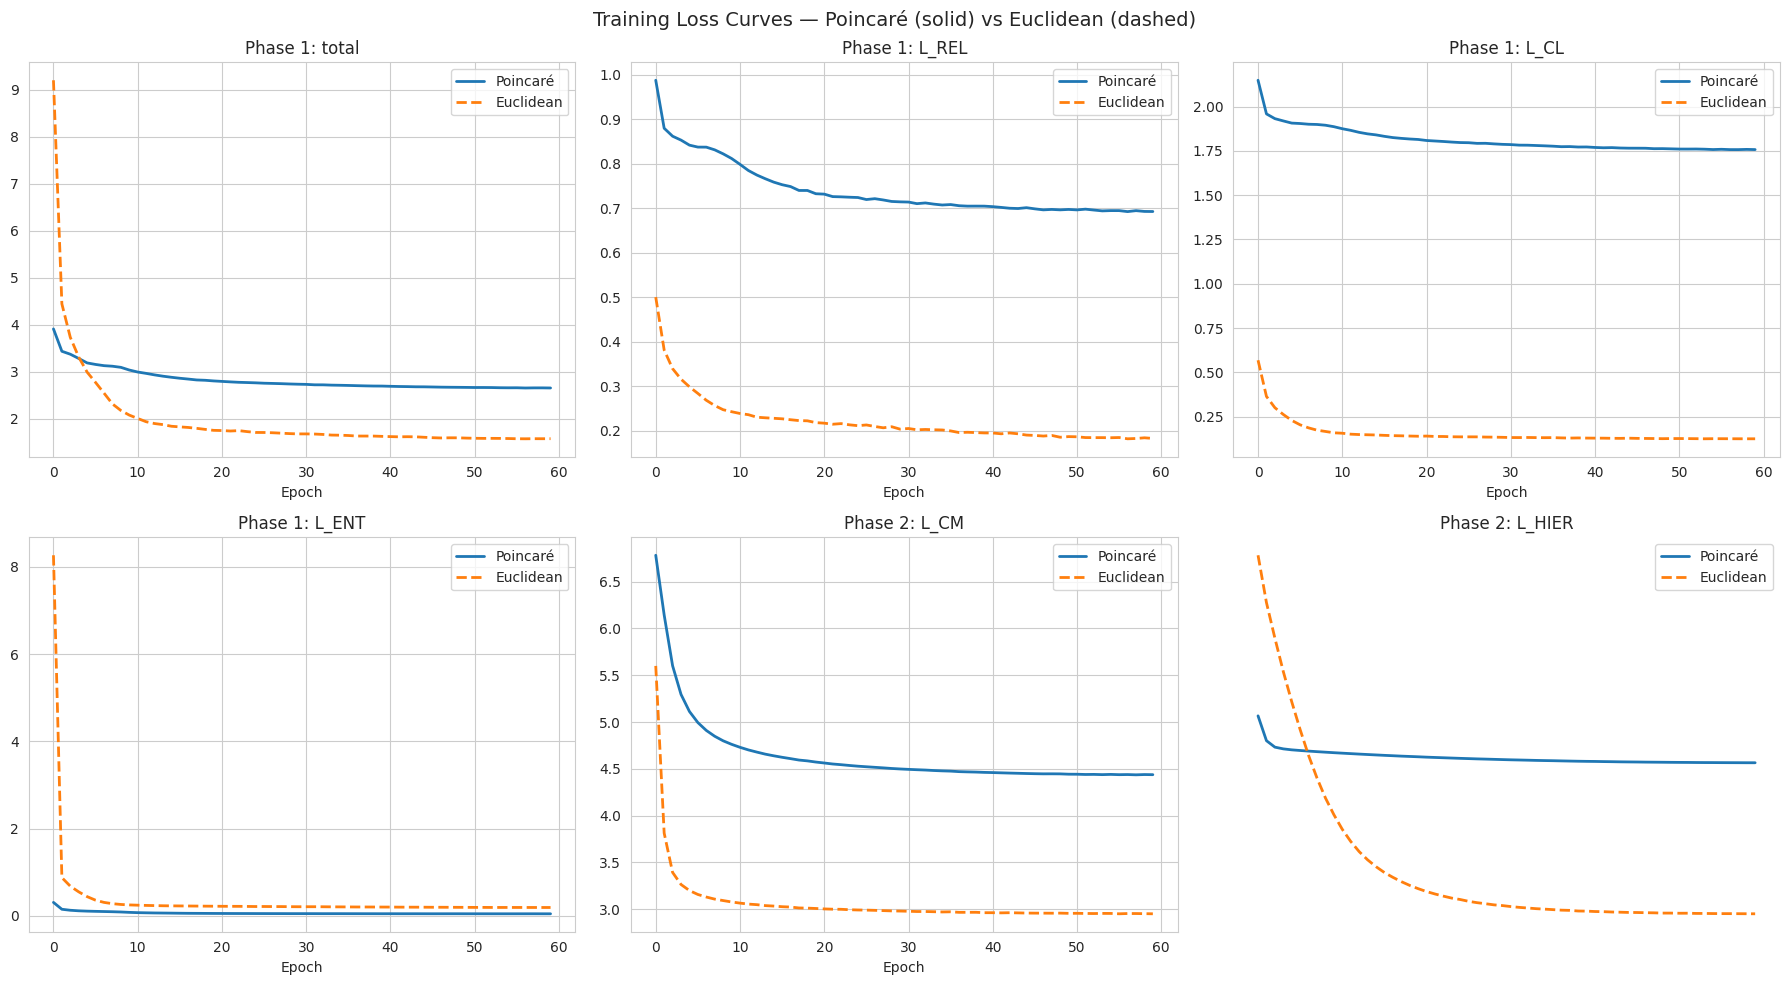

In [16]:
# ── 9a. Loss Curves: Poincaré vs Euclidean ────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Loss Curves — Poincaré (solid) vs Euclidean (dashed)', fontsize=14)

for ax, key in zip(axes.flat[:4], ['total', 'L_REL', 'L_CL', 'L_ENT']):
    if key in history_p1:
        ax.plot(history_p1[key], label=f'Poincaré', linewidth=2)
    if key in history_e1:
        ax.plot(history_e1[key], label=f'Euclidean', linewidth=2, linestyle='--')
    ax.set_title(f'Phase 1: {key}'); ax.set_xlabel('Epoch'); ax.legend()

for ax, key in zip(axes.flat[4:], ['L_CM', 'L_HIER']):
    if key in history_p2:
        ax.plot(history_p2[key], label='Poincaré', linewidth=2)
    if key in history_e2:
        ax.plot(history_e2[key], label='Euclidean', linewidth=2, linestyle='--')
    ax.set_title(f'Phase 2: {key}'); ax.set_xlabel('Epoch'); ax.legend()

axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('usm_scale_losses.png', dpi=120, bbox_inches='tight')
plt.show()

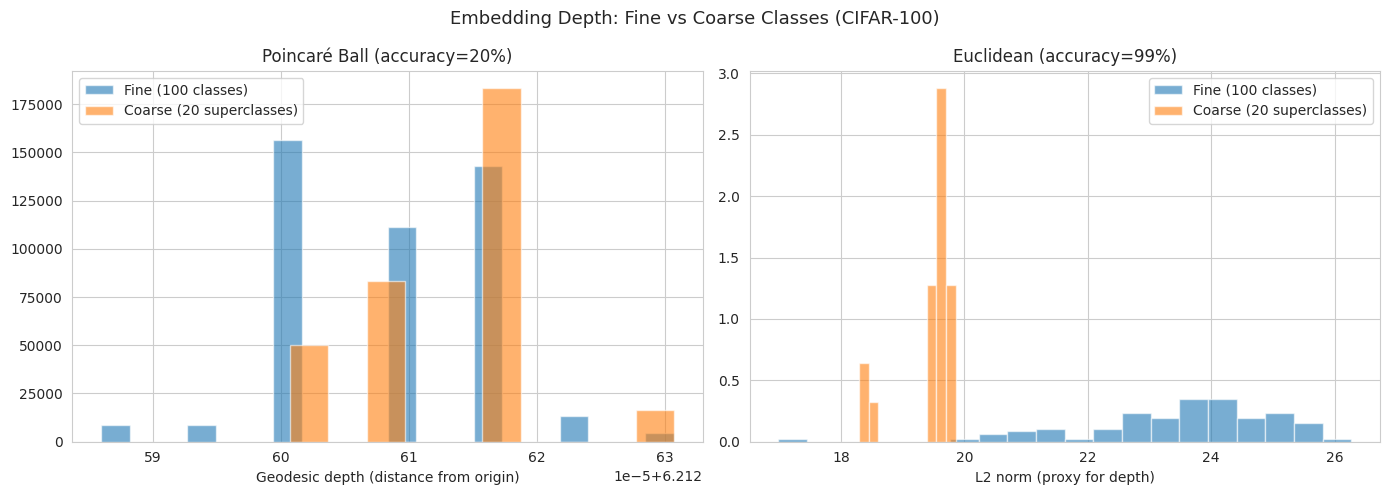

In [17]:
# ── 9b. Hierarchy Norm Histogram ──────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Embedding Depth: Fine vs Coarse Classes (CIFAR-100)', fontsize=13)

ax1.hist(hier_poinc['fine_depths'], bins=20, alpha=0.6, label='Fine (100 classes)', density=True)
ax1.hist(hier_poinc['coarse_depths'], bins=10, alpha=0.6, label='Coarse (20 superclasses)', density=True)
ax1.set_title(f'Poincaré Ball (accuracy={hier_poinc["accuracy"]:.0%})')
ax1.set_xlabel('Geodesic depth (distance from origin)'); ax1.legend()

ax2.hist(hier_eucl['fine_depths'], bins=20, alpha=0.6, label='Fine (100 classes)', density=True)
ax2.hist(hier_eucl['coarse_depths'], bins=10, alpha=0.6, label='Coarse (20 superclasses)', density=True)
ax2.set_title(f'Euclidean (accuracy={hier_eucl["accuracy"]:.0%})')
ax2.set_xlabel('L2 norm (proxy for depth)'); ax2.legend()

plt.tight_layout()
plt.savefig('usm_scale_hierarchy.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# ── 9c. Results Summary Table ─────────────────────────────────────────────────

print('=' * 60)
print('        USM SCALE PUSH — RESULTS SUMMARY')
print('=' * 60)

print(f'\n{"":<25} {"Poincaré":>12} {"Euclidean":>12}  {"Δ":>8}')
print('─' * 60)

print('\n  KG Link Prediction (ConceptNet held-out):')
for k in ['MRR', 'Hits@1', 'Hits@10']:
    p, e = lp_poincare[k], lp_eucl[k]
    d = p - e
    print(f'    {k:<21} {p:>12.4f} {e:>12.4f}  {d:>+8.4f}')

print('\n  Cross-Modal Retrieval (CIFAR-100 Image→Text):')
for k in ['R@1', 'R@5', 'R@10', 'MedR']:
    p, e = cm_poincare[k], cm_eucl[k]
    d = p - e
    sign = '+' if (k != 'MedR' and d > 0) or (k == 'MedR' and d < 0) else ''
    print(f'    {k:<21} {p:>12.4f} {e:>12.4f}  {d:>+8.4f}')

print('\n  Hierarchy Depth (fine > coarse %):')
p, e = hier_poinc['accuracy'], hier_eucl['accuracy']
print(f'    {"Accuracy":<21} {p:>12.1%} {e:>12.1%}  {p-e:>+8.1%}')

print('\n' + '=' * 60)
print('Positive Δ = Poincaré wins (except MedR where lower is better).')
print('=' * 60)

        USM SCALE PUSH — RESULTS SUMMARY

                              Poincaré    Euclidean         Δ
────────────────────────────────────────────────────────────

  KG Link Prediction (ConceptNet held-out):
    MRR                         0.0100       0.0272   -0.0171
    Hits@1                      0.0045       0.0130   -0.0085
    Hits@10                     0.0175       0.0535   -0.0360

  Cross-Modal Retrieval (CIFAR-100 Image→Text):
    R@1                         0.6880       0.8490   -0.1610
    R@5                         0.8995       0.9665   -0.0670
    R@10                        0.9360       0.9835   -0.0475
    MedR                        1.0000       1.0000   +0.0000

  Hierarchy Depth (fine > coarse %):
    Accuracy                     20.0%        99.0%    -79.0%

Positive Δ = Poincaré wins (except MedR where lower is better).


In [19]:
# ── 9d. Temperature-Controlled Cross-Modal Navigation ─────────────────────────

# Pre-compute kNN density for Poincaré
print('Computing kNN density...')
KNN_K = 10
with torch.no_grad():
    all_concept_z = torch.cat([
        encoder.project(vocab_bb[:500]).cpu()
    ] + [cifar_fine_z.cpu()], dim=0)
    all_concept_labels = vocab_list[:500] + [f'[IMG]{c}' for c in CIFAR100_FINE]

    acg = all_concept_z.to(device)
    V = acg.shape[0]
    d_k_vals = []
    for s in range(0, V, 128):
        e = min(s+128, V)
        dists = poincare_cdist(acg[s:e], acg)
        kth = dists.topk(KNN_K+1, largest=False).values[:, -1]
        d_k_vals.append(kth.cpu())
    d_k = torch.cat(d_k_vals)
    log_rho = -torch.log(d_k.clamp(min=1e-6))
    log_rho = (log_rho - log_rho.mean()) / (log_rho.std() + 1e-8)
    log_rho_gpu = log_rho.to(device)

LAMBDA_RHO = 0.5
TAUS = [0.01, 0.1, 1.0, 5.0]
QUERIES = ['dolphin', 'fire', 'tree', 'car']

print(f'\n{"Query":<12} {"τ":>5}   Top-5 (score | dist | type)')
print('─' * 90)

for query in QUERIES:
    with torch.no_grad():
        z_q = encoder.project(encoder.encode_backbone([query])).squeeze(0)
        dists = poincare_cdist(z_q.unsqueeze(0), acg).squeeze(0)
    for tau in TAUS:
        score = -dists / tau + LAMBDA_RHO * log_rho_gpu
        top5 = score.topk(5).indices.tolist()
        parts = []
        for idx in top5:
            name = all_concept_labels[idx]
            parts.append(f'{name}(s={score[idx]:.1f},d={dists[idx]:.1f})')
        print(f'{query:<12} {tau:>5.2f}   {"  ".join(parts)}')
    print()

Computing kNN density...

Query            τ   Top-5 (score | dist | type)
──────────────────────────────────────────────────────────────────────────────────────────
dolphin       0.01   [IMG]dolphin(s=0.2,d=0.0)  [IMG]whale(s=-586.5,d=5.9)  [IMG]shark(s=-672.1,d=6.7)  [IMG]seal(s=-750.1,d=7.5)  [IMG]turtle(s=-760.3,d=7.6)
dolphin       0.10   [IMG]dolphin(s=0.3,d=0.0)  [IMG]whale(s=-58.4,d=5.9)  [IMG]shark(s=-66.9,d=6.7)  [IMG]seal(s=-74.7,d=7.5)  [IMG]turtle(s=-75.3,d=7.6)
dolphin       1.00   [IMG]dolphin(s=0.3,d=0.0)  [IMG]whale(s=-5.6,d=5.9)  [IMG]shark(s=-6.4,d=6.7)  [IMG]turtle(s=-6.8,d=7.6)  [IMG]otter(s=-7.0,d=7.6)
dolphin       5.00   [IMG]dolphin(s=0.3,d=0.0)  abar(s=-0.7,d=9.0)  [IMG]squirrel(s=-0.7,d=8.9)  [IMG]beaver(s=-0.7,d=8.4)  [IMG]turtle(s=-0.8,d=7.6)

fire          0.01   absense of light(s=-801.5,d=8.0)  ablaze(s=-807.3,d=8.1)  above ground(s=-846.5,d=8.5)  [IMG]bottle(s=-854.1,d=8.5)  ability to move(s=-856.5,d=8.6)
fire          0.10   absense of light(s=-80.1,d

UMAP fitting...


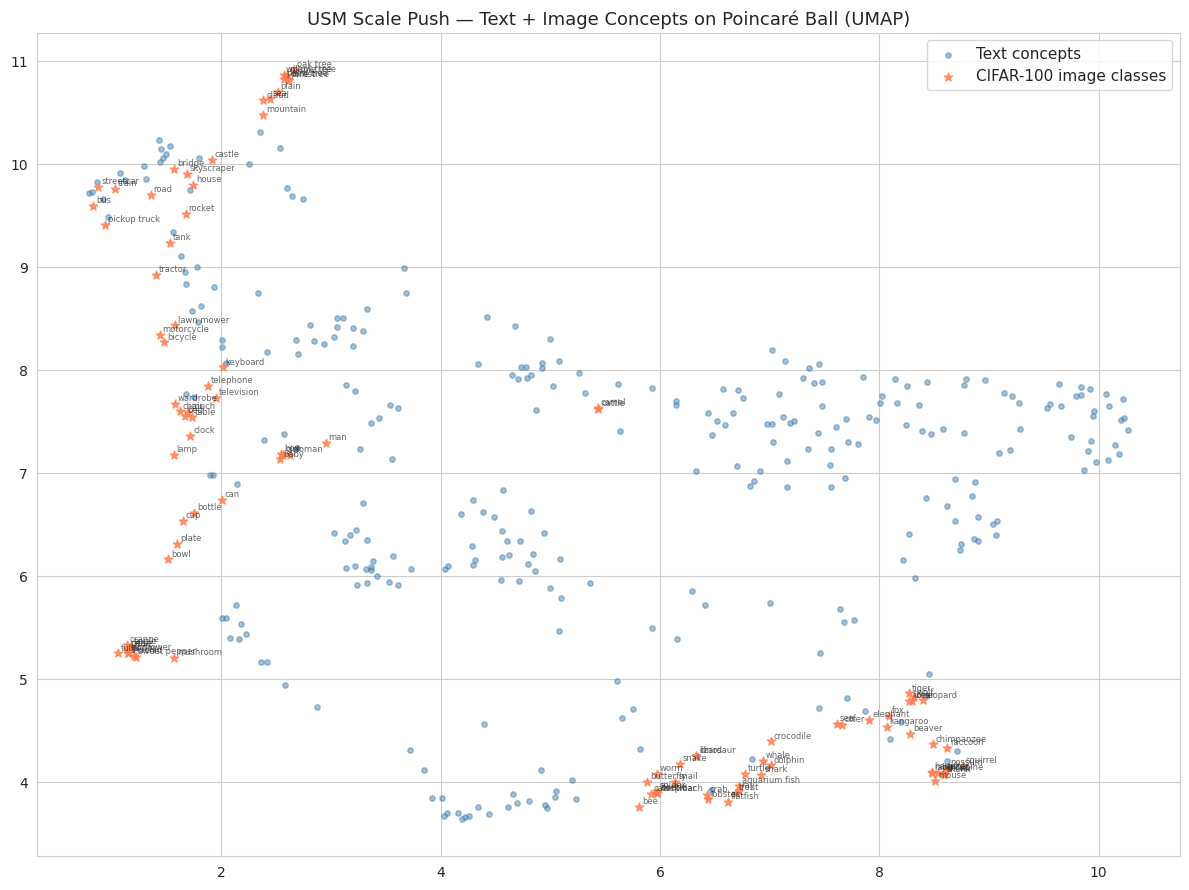


=== All evaluations complete ===


In [20]:
# ── 9e. UMAP: Text + Image Concepts ───────────────────────────────────────────
import umap

print('UMAP fitting...')
# Combine text concepts + CIFAR fine class embeddings
N_TEXT_UMAP = min(300, vocab_bb.shape[0])
with torch.no_grad():
    text_subset_z = encoder.project(vocab_bb[:N_TEXT_UMAP])
    img_class_z = cifar_fine_z
    combined_z = torch.cat([text_subset_z, img_class_z], dim=0)
    combined_tan = logmap0(combined_z).cpu().numpy()

labels_combined = ['text'] * N_TEXT_UMAP + ['image'] * 100

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED)
umap_2d = reducer.fit_transform(combined_tan)

fig, ax = plt.subplots(figsize=(12, 9))
text_mask = [i for i, l in enumerate(labels_combined) if l == 'text']
img_mask  = [i for i, l in enumerate(labels_combined) if l == 'image']

ax.scatter(umap_2d[text_mask, 0], umap_2d[text_mask, 1], c='steelblue',
           s=15, alpha=0.5, label='Text concepts')
ax.scatter(umap_2d[img_mask, 0], umap_2d[img_mask, 1], c='coral',
           s=40, alpha=0.8, label='CIFAR-100 image classes', marker='*')

# Label image classes
for i, idx in enumerate(img_mask):
    ax.annotate(CIFAR100_FINE[i], umap_2d[idx], fontsize=6, alpha=0.7,
                xytext=(2, 2), textcoords='offset points')

ax.legend(fontsize=11)
ax.set_title('USM Scale Push — Text + Image Concepts on Poincaré Ball (UMAP)', fontsize=13)
plt.tight_layout()
plt.savefig('usm_scale_umap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== All evaluations complete ===')